Min: 0.01000719965141448
Max: 0.04379493088697446
Mean: 0.03949621910995052


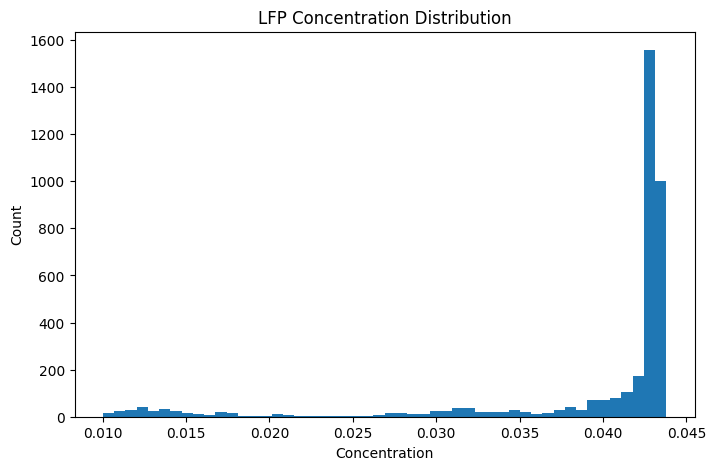

In [1]:
import numpy as np
import matplotlib.pyplot as plt

file_path = "../outputs/Results/20260701_153151__nsteps=1__mesh=colored_labels_labels/CnP_total_20000"
values = []

with open(file_path, "r") as f:
    for line in f:

        # skip MFEM header
        try:
            values.append(float(line.strip()))
        except:
            pass

values = np.array(values)

# remove electrolyte/background
particle_values = values[values > 1e-2]

print("Min:", particle_values.min())
print("Max:", particle_values.max())
print("Mean:", particle_values.mean())

plt.figure(figsize=(8,5))
plt.hist(particle_values, bins=50)
plt.xlabel("Concentration")
plt.ylabel("Count")
plt.title("LFP Concentration Distribution")
plt.show()

In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# ============================================================
# LOAD FIXED PSI FIELD
# ============================================================

psi_file = os.path.join("../outputs/Results/20260701_153056__nsteps=1__mesh=colored_labels_labels/psi")   # change filename if needed

values = []

with open("../outputs/Results/20260701_153056__nsteps=1__mesh=colored_labels_labels/psi", "r") as f:
    for line in f:
        try:
            values.append(float(line.strip()))
        except:
            pass

psi = np.array(values)

# psi = np.loadtxt(psi_file)

psi_threshold = 0.95
particle_mask = psi > psi_threshold

print("Psi nodes kept:", np.sum(particle_mask))
print("Total nodes:", len(psi))

# ============================================================
# DIRECTORY
# ============================================================

data_dir = "../outputs/Results/20260702_091120__nsteps=1__mesh=colored_labels_labels"

# ============================================================
# FIND ALL CnP FILES
# ============================================================

files = []

for fname in os.listdir(data_dir):
    match = re.match(r"CnP_total_(\d+)$", fname)

    if match:
        timestep = int(match.group(1))
        files.append((timestep, fname))

files.sort()

print(f"Found {len(files)} files")

# ============================================================
# TEMP FRAME DIRECTORY
# ============================================================

frame_dir = "hist_frames"
os.makedirs(frame_dir, exist_ok=True)

# ============================================================
# CREATE HISTOGRAM FRAMES
# ============================================================

all_frames = []
#  ============================================================
# PASS 1: FIND GLOBAL MAX HISTOGRAM COUNT
# ============================================================

global_max = 0

for timestep, fname in files:

    filepath = os.path.join(data_dir, fname)

    values = []

    with open(filepath, "r") as f:
        for line in f:
            try:
                values.append(float(line.strip()))
            except:
                pass

    values = np.array(values)

    particle_values = values[particle_mask]

    if len(particle_values) == 0:
        continue

    counts, _ = np.histogram(
        particle_values,
        bins=50,
        range=(0, 1)
    )

    global_max = max(global_max, counts.max())

print("Global max count =", global_max)

# ============================================================
# PASS 2: CREATE FRAMES
# ============================================================

for timestep, fname in files:

    filepath = os.path.join(data_dir, fname)

    values = []

    with open(filepath, "r") as f:
        for line in f:
            try:
                values.append(float(line.strip()))
            except:
                pass

    values = np.array(values)

    particle_values = values[particle_mask]

    if len(particle_values) == 0:
        continue

    plt.figure(figsize=(8,5))

    plt.hist(
        particle_values,
        bins=50,
        range=(0,1)
    )

    plt.xlim(0,1)
    plt.ylim(0, global_max * 1.05)   # fixed y-axis

    plt.xlabel("Concentration")
    plt.ylabel("Count")
    plt.title(f"Timestep = {timestep}")

    frame_file = os.path.join(
        frame_dir,
        f"frame_{timestep:08d}.png"
    )

    plt.savefig(frame_file, dpi=150)
    plt.close()

    all_frames.append(frame_file)


video_file = "LFP_histogram_evolution.mp4"

writer = imageio.get_writer(
    video_file,
    fps=15
)

for frame in all_frames:
    writer.append_data(imageio.imread(frame))

writer.close()

print(f"\nVideo saved to: {video_file}")

Psi nodes kept: 2807
Total nodes: 6815
Found 248 files
Global max count = 2807


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1200, 750) to (1200, 752) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).



Video saved to: LFP_histogram_evolution.mp4


In [ ]:
# import os
# import re
# import numpy as np
# import matplotlib.pyplot as plt
# import imageio.v2 as imageio

# # ============================================================
# # DIRECTORY
# # ============================================================

# data_dir = "../outputs/Results/20260608_135001__nsteps=3000001__mesh=colored_labels_labels"

# # ============================================================
# # FIND ALL CnP FILES
# # ============================================================

# files = []

# for fname in os.listdir(data_dir):
#     match = re.match(r"CnP_total_(\d+)$", fname)

#     if match:
#         timestep = int(match.group(1))
#         files.append((timestep, fname))

# files.sort()

# print(f"Found {len(files)} files")

# # ============================================================
# # TEMP FRAME DIRECTORY
# # ============================================================

# frame_dir = "hist_frames"
# os.makedirs(frame_dir, exist_ok=True)

# # ============================================================
# # CREATE HISTOGRAM FRAMES
# # ============================================================

# all_frames = []

# for timestep, fname in files:

#     filepath = os.path.join(data_dir, fname)

#     values = []

#     with open(filepath, "r") as f:
#         for line in f:
#             try:
#                 values.append(float(line.strip()))
#             except:
#                 pass

#     values = np.array(values)

#     # remove electrolyte/background
#     particle_values = values[values > 1e-2]

#     if len(particle_values) == 0:
#         continue

#     plt.figure(figsize=(8,5))

#     plt.hist(
#         particle_values,
#         bins=50,
#         range=(0,1),      # keep axes fixed
#     )

#     plt.xlim(0,1)

#     plt.xlabel("Concentration")
#     plt.ylabel("Count")
#     plt.title(f"Timestep = {timestep}")

#     frame_file = os.path.join(
#         frame_dir,
#         f"frame_{timestep:08d}.png"
#     )

#     plt.savefig(frame_file, dpi=150)
#     plt.close()

#     all_frames.append(frame_file)

#     print("Saved:", frame_file)

# # ============================================================
# # BUILD VIDEO
# # ============================================================

# video_file = "LFP_histogram_evolution.mp4"

# writer = imageio.get_writer(
#     video_file,
#     fps=15
# )

# for frame in all_frames:
#     writer.append_data(imageio.imread(frame))

# writer.close()

# print(f"\nVideo saved to: {video_file}")